   Python_Skill  ML_Skill  Networking_Skill  Cloud_Skill  SQL_Skill  \
0            68        45                80           88         57   
1            69        40                88           79         94   
2            56        54                69           76         36   
3            90         8                12           75         56   
4            85        71                42            4         79   

          Predicted_Role  
0  Cybersecurity Analyst  
1  Cybersecurity Analyst  
2        DevOps Engineer  
3          Web Developer  
4           Data Analyst  
   Python_Skill  ML_Skill  Networking_Skill  Cloud_Skill  SQL_Skill
0            68        45                80           88         57
1            69        40                88           79         94
2            56        54                69           76         36
3            90         8                12           75         56
4            85        71                42            4         79


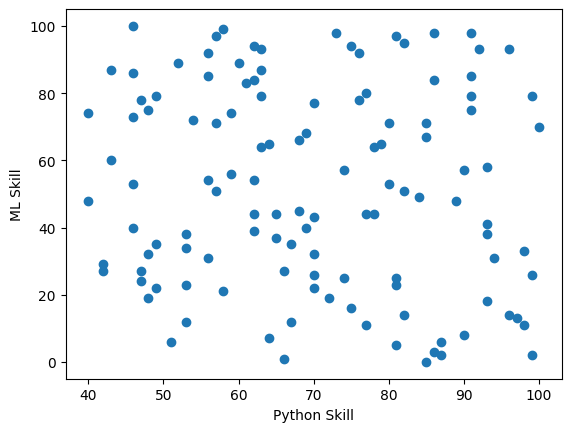

[2 2 2 1 0 1 2 2 0 0 0 0 1 2 1 2 0 1 1 0 2 0 0 0 0 0 1 2 1 0 0 0 0 0 2 0 2
 0 2 2 0 1 2 1 1 0 0 1 1 2 2 0 1 2 0 0 0 2 2 0 2 0 2 2 0 2 0 0 1 0 2 0 1 0
 1 0 0 0 2 0 2 0 1 0 1 2 1 1 0 0 0 1 0 0 2 1 2 0 2 1 2 0 2 0 1 1 0 2 1 2 2
 2 0 2 1 2 2 0 2 0]
   Python_Skill  ML_Skill  Networking_Skill  Cloud_Skill  SQL_Skill  cluster
0            68        45                80           88         57        2
1            69        40                88           79         94        2
2            56        54                69           76         36        2
3            90         8                12           75         56        1
4            85        71                42            4         79        0
[[69.90384615 81.17307692]
 [83.42857143 15.42857143]
 [60.125      38.7       ]]


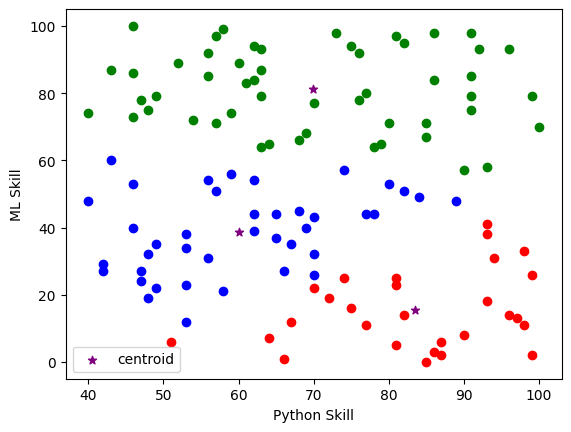

   Python_Skill  ML_Skill  Networking_Skill  Cloud_Skill  SQL_Skill  cluster
0      0.466667      0.45                80           88         57        2
1      0.483333      0.40                88           79         94        2
2      0.266667      0.54                69           76         36        2
3      0.833333      0.08                12           75         56        1
4      0.750000      0.71                42            4         79        0


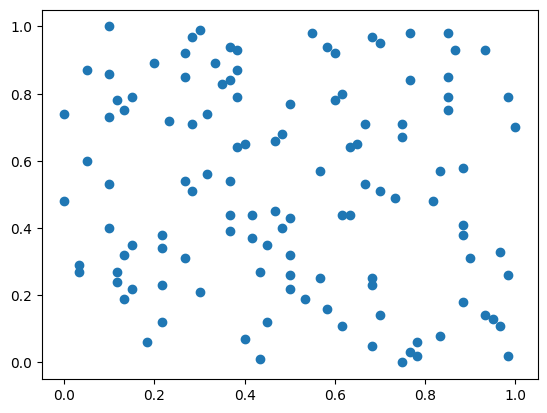

[2 2 2 0 1 0 2 2 1 1 1 1 0 2 0 0 0 0 2 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 2 1 2
 1 2 2 1 0 2 0 0 1 1 0 0 2 2 1 0 2 1 1 1 2 2 1 2 1 2 0 1 2 1 1 0 1 0 1 2 1
 2 1 1 1 2 1 2 0 0 1 0 2 0 0 1 1 1 0 1 1 2 0 2 1 2 0 2 1 2 1 2 0 1 2 2 0 2
 0 1 2 0 2 2 0 2 1]
   Python_Skill  ML_Skill  Networking_Skill  Cloud_Skill  SQL_Skill  cluster
0      0.466667      0.45                80           88         57        2
1      0.483333      0.40                88           79         94        2
2      0.266667      0.54                69           76         36        2
3      0.833333      0.08                12           75         56        0
4      0.750000      0.71                42            4         79        1
[[0.78697917 0.268125  ]
 [0.47533333 0.8186    ]
 [0.28026316 0.32894737]]


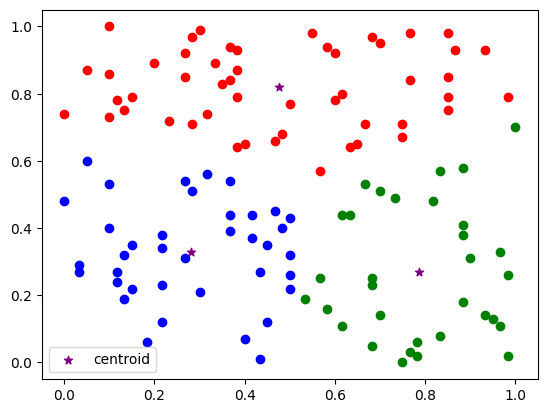

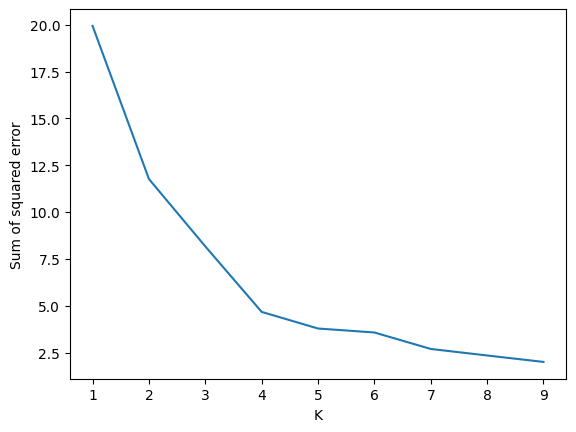

In [2]:


from sklearn.cluster import KMeans

import pandas as pd

from sklearn.preprocessing import MinMaxScaler

from matplotlib import pyplot as plt

%matplotlib inline



df = pd.read_csv('/content/multiclass_role_prediction_dataset.csv')

print(df.head())



df = df.drop('Predicted_Role', axis='columns')

print(df.head())



plt.scatter(df.Python_Skill, df.ML_Skill)

plt.xlabel('Python Skill')

plt.ylabel('ML Skill')

plt.show()



km = KMeans(
    n_clusters=3
)




y_predicted = km.fit_predict(
    df[['Python_Skill', 'ML_Skill']]
)

print(y_predicted)



df['cluster'] = y_predicted

print(df.head())



print(km.cluster_centers_)



df1 = df[df.cluster == 0]

df2 = df[df.cluster == 1]

df3 = df[df.cluster == 2]


plt.scatter(
    df1.Python_Skill,
    df1.ML_Skill,
    color='green'
)

plt.scatter(
    df2.Python_Skill,
    df2.ML_Skill,
    color='red'
)

plt.scatter(
    df3.Python_Skill,
    df3.ML_Skill,
    color='blue'
)



plt.scatter(
    km.cluster_centers_[:,0],
    km.cluster_centers_[:,1],
    color='purple',
    marker='*',
    label='centroid'
)

plt.xlabel('Python Skill')

plt.ylabel('ML Skill')

plt.legend()

plt.show()



scaler = MinMaxScaler()



scaler.fit(df[['Python_Skill']])

df['Python_Skill'] = scaler.transform(
    df[['Python_Skill']]
)



scaler.fit(df[['ML_Skill']])

df['ML_Skill'] = scaler.transform(
    df[['ML_Skill']]
)

print(df.head())



plt.scatter(
    df.Python_Skill,
    df.ML_Skill
)

plt.show()



km = KMeans(
    n_clusters=3
)

y_predicted = km.fit_predict(
    df[['Python_Skill', 'ML_Skill']]
)

print(y_predicted)



df['cluster'] = y_predicted

print(df.head())



print(km.cluster_centers_)



df1 = df[df.cluster == 0]

df2 = df[df.cluster == 1]

df3 = df[df.cluster == 2]


plt.scatter(
    df1.Python_Skill,
    df1.ML_Skill,
    color='green'
)

plt.scatter(
    df2.Python_Skill,
    df2.ML_Skill,
    color='red'
)

plt.scatter(
    df3.Python_Skill,
    df3.ML_Skill,
    color='blue'
)

plt.scatter(
    km.cluster_centers_[:,0],
    km.cluster_centers_[:,1],
    color='purple',
    marker='*',
    label='centroid'
)

plt.legend()

plt.show()



sse = []

k_rng = range(1,10)

for k in k_rng:

    km = KMeans(n_clusters=k)

    km.fit(
        df[['Python_Skill', 'ML_Skill']]
    )

    sse.append(km.inertia_)


plt.xlabel('K')

plt.ylabel('Sum of squared error')

plt.plot(k_rng, sse)

plt.show()